In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/models/jorgeoc/emg-modelos-v1/pytorch/v1-myoware-pipeline/1/intent_binary_best.pt
/kaggle/input/models/jorgeoc/emg-modelos-v1/pytorch/v1-myoware-pipeline/1/restorer_best.pt
/kaggle/input/models/jorgeoc/emg-modelos-v1/pytorch/v1-myoware-pipeline/1/quality_judge_best.pt
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0032.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0026.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0040.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0056.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/X_0009.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0011.npy
/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/intent_dataset/Y_0018.npy
/kaggle/input/datasets/jorgeoc/prepare

In [2]:
# =========================
# CELDA 1: Imports
# =========================
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

In [3]:
# =========================
# CELDA 2: Arquitecturas
# =========================
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=5, dilation=1, drop=0.1):
        super().__init__()
        pad = (k - 1) * dilation // 2
        self.conv1 = nn.Conv1d(in_ch, out_ch, k, padding=pad, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, k, padding=pad, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.act = nn.ReLU()
        self.drop = nn.Dropout(drop)
        self.skip = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        s = self.skip(x)
        x = self.drop(self.act(self.bn1(self.conv1(x))))
        x = self.drop(self.act(self.bn2(self.conv2(x))))
        return self.act(x + s)

class IntentTCN(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1, 16, 7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
        )
        self.tcn = nn.Sequential(
            TCNBlock(16, 16, dilation=1, drop=0.10),
            TCNBlock(16, 32, dilation=2, drop=0.10),
            TCNBlock(32, 32, dilation=4, drop=0.10),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.tcn(x)
        x = self.pool(x)
        return self.head(x)

class QualityNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, 7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, 5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, 5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

        self.shared = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        self.head_score = nn.Linear(32, 1)
        self.head_label = nn.Linear(32, 1)

    def forward(self, x):
        z = self.features(x)
        z = self.shared(z)
        q_score = torch.sigmoid(self.head_score(z))
        q_logit = self.head_label(z)
        return q_score, q_logit

class ConvAE1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 16, 5, stride=2, padding=2),
            nn.BatchNorm1d(16),
            nn.ReLU(),

            nn.Conv1d(16, 32, 5, stride=2, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.Conv1d(32, 64, 5, stride=2, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )

        self.bottleneck = nn.Sequential(
            nn.Conv1d(64, 64, 3, padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(64, 32, 4, stride=2, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            nn.ConvTranspose1d(32, 16, 4, stride=2, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),

            nn.ConvTranspose1d(16, 1, 4, stride=2, padding=1),
        )

    def forward(self, x):
        z = self.encoder(x)
        z = self.bottleneck(z)
        y = self.decoder(z)
        return y

In [4]:
# =========================
# CELDA 3: Verificación de clases
# =========================
print("IntentTCN definido:", "IntentTCN" in globals())
print("QualityNet definido:", "QualityNet" in globals())
print("ConvAE1D definido:", "ConvAE1D" in globals())

"""
debe verse
IntentTCN definido: True
QualityNet definido: True
ConvAE1D definido: True
"""

IntentTCN definido: True
QualityNet definido: True
ConvAE1D definido: True


'\ndebe verse\nIntentTCN definido: True\nQualityNet definido: True\nConvAE1D definido: True\n'

In [5]:
# =========================
# CELDA 4: Cargar modelos
# =========================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

MODELS_DIR = "/kaggle/input/models/jorgeoc/emg-modelos-v1/pytorch/v1-myoware-pipeline/1"

for p in [
    f"{MODELS_DIR}/intent_binary_best.pt",
    f"{MODELS_DIR}/quality_judge_best.pt",
    f"{MODELS_DIR}/restorer_best.pt",
]:
    print(p, os.path.exists(p))

intent_model = IntentTCN().to(device)
intent_model.load_state_dict(torch.load(f"{MODELS_DIR}/intent_binary_best.pt", map_location=device))
intent_model.eval()

quality_model = QualityNet().to(device)
quality_model.load_state_dict(torch.load(f"{MODELS_DIR}/quality_judge_best.pt", map_location=device))
quality_model.eval()

restorer_model = ConvAE1D().to(device)
restorer_model.load_state_dict(torch.load(f"{MODELS_DIR}/restorer_best.pt", map_location=device))
restorer_model.eval()

print("Modelos cargados correctamente.")

device: cuda
/kaggle/input/models/jorgeoc/emg-modelos-v1/pytorch/v1-myoware-pipeline/1/intent_binary_best.pt True
/kaggle/input/models/jorgeoc/emg-modelos-v1/pytorch/v1-myoware-pipeline/1/quality_judge_best.pt True
/kaggle/input/models/jorgeoc/emg-modelos-v1/pytorch/v1-myoware-pipeline/1/restorer_best.pt True
Modelos cargados correctamente.


In [6]:
# =========================
# CELDA 5: Política del pipeline
# =========================
THR_INTENT = 0.50
THR_QUALITY = 0.50

@torch.no_grad()
def run_pipeline_on_batch(x_batch):
    """
    x_batch: np.array con forma (N, 1, T)
    devuelve:
      out: lista de dicts
      restored: np.array (N, 1, T)
    """
    xb = torch.tensor(x_batch, dtype=torch.float32, device=device)

    # Intent
    intent_logits = intent_model(xb)
    p_intent = torch.sigmoid(intent_logits).cpu().numpy().reshape(-1)

    # Quality
    q_score_pred, q_logit = quality_model(xb)
    q_score_pred = q_score_pred.cpu().numpy().reshape(-1)
    q_prob_good = torch.sigmoid(q_logit).cpu().numpy().reshape(-1)

    out = []
    restored = []

    for i in range(len(x_batch)):
        pi = float(p_intent[i])
        qg = float(q_prob_good[i])
        qs = float(q_score_pred[i])

        if pi < THR_INTENT:
            decision = "skip_restore"
            reason = "no_intent_detected"
        elif qg >= THR_QUALITY:
            decision = "skip_restore"
            reason = "signal_quality_good_enough"
        else:
            decision = "restore"
            reason = "intent_detected_and_quality_bad"

        if decision == "restore":
            xr = restorer_model(xb[i:i+1]).cpu().numpy()[0]
        else:
            xr = x_batch[i].copy()

        restored.append(xr)
        out.append({
            "p_intent": pi,
            "q_score_pred": qs,
            "q_prob_good": qg,
            "decision": decision,
            "reason": reason
        })

    restored = np.stack(restored).astype(np.float32)
    return out, restored

In [7]:
# =========================
# CELDA 6: Evaluación pipeline
# =========================
candidate_dirs = []

for p in glob.glob("/kaggle/input/**/restoration_dataset", recursive=True):
    if os.path.isdir(p):
        xcorr = glob.glob(os.path.join(p, "Xcorr_*.npy"))
        xclean = glob.glob(os.path.join(p, "Xclean_*.npy"))
        qscore = glob.glob(os.path.join(p, "Qscore_*.npy"))
        if len(xcorr) > 0 and len(xclean) > 0 and len(qscore) > 0:
            candidate_dirs.append(p)

print("Candidatos encontrados:")
for c in candidate_dirs:
    print(" -", c)

if not candidate_dirs:
    raise FileNotFoundError("No encontré ningún restoration_dataset válido en /kaggle/input")

RDIR = candidate_dirs[0]
print("\nUsando RDIR:", RDIR)

Xcorr_files = sorted(glob.glob(os.path.join(RDIR, "Xcorr_*.npy")))
Xclean_files = sorted(glob.glob(os.path.join(RDIR, "Xclean_*.npy")))
Qscore_files = sorted(glob.glob(os.path.join(RDIR, "Qscore_*.npy")))

print("restoration shards Xcorr:", len(Xcorr_files))
print("restoration shards Xclean:", len(Xclean_files))
print("restoration shards Qscore:", len(Qscore_files))
print("Ejemplo Xcorr:", Xcorr_files[:3])
print("Ejemplo Xclean:", Xclean_files[:3])
print("Ejemplo Qscore:", Qscore_files[:3])

if len(Xcorr_files) == 0 or len(Xclean_files) == 0:
    raise FileNotFoundError("Se encontró restoration_dataset, pero no hay shards utilizables.")

x_corr = np.load(Xcorr_files[0])
x_clean = np.load(Xclean_files[0])

N = min(2000, len(x_corr))
x_corr = x_corr[:N]
x_clean = x_clean[:N]

rows, x_out = run_pipeline_on_batch(x_corr)

def mse_np(a, b):
    return float(np.mean((a - b) ** 2))

def mae_np(a, b):
    return float(np.mean(np.abs(a - b)))

def snr_db(clean, noisy):
    noise = noisy - clean
    ps = np.mean(clean**2) + 1e-8
    pn = np.mean(noise**2) + 1e-8
    return 10 * np.log10(ps / pn)

records = []
for i, row in enumerate(rows):
    clean = x_clean[i, 0]
    corr  = x_corr[i, 0]
    out   = x_out[i, 0]

    records.append({
        **row,
        "mae_before": mae_np(clean, corr),
        "mae_after": mae_np(clean, out),
        "snr_before": snr_db(clean, corr),
        "snr_after": snr_db(clean, out),
        "improved_mae": mae_np(clean, out) < mae_np(clean, corr),
        "improved_snr": snr_db(clean, out) > snr_db(clean, corr),
    })

df = pd.DataFrame(records)
print(df.head())
print("Total evaluadas:", len(df))

Candidatos encontrados:
 - /kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/restoration_dataset

Usando RDIR: /kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/restoration_dataset
restoration shards Xcorr: 32
restoration shards Xclean: 32
restoration shards Qscore: 32
Ejemplo Xcorr: ['/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/restoration_dataset/Xcorr_0000.npy', '/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/restoration_dataset/Xcorr_0001.npy', '/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/restoration_dataset/Xcorr_0002.npy']
Ejemplo Xclean: ['/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/restoration_dataset/Xclean_0000.npy', '/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/restoration_dataset/Xclean_0001.npy', '/kaggle/input/datasets/jorgeoc/prepared-myoware-v2/prepared_myoware_v2/restoration_dataset/Xclean_0002.npy'

In [8]:
# =========================
# CELDA 7: Resumen
# =========================
print("Conteo de decisiones:")
print(df["decision"].value_counts(dropna=False))
print()

print("Razones:")
print(df["reason"].value_counts(dropna=False))
print()

print("Promedios globales:")
print(df[["mae_before", "mae_after", "snr_before", "snr_after"]].mean())

print("\nSolo restauradas:")
dfr = df[df["decision"] == "restore"]
if len(dfr):
    print(dfr[["mae_before", "mae_after", "snr_before", "snr_after"]].mean())
    print("Frac mejora MAE:", dfr["improved_mae"].mean())
    print("Frac mejora SNR:", dfr["improved_snr"].mean())

print("\nNo restauradas:")
dfs = df[df["decision"] == "skip_restore"]
if len(dfs):
    print(dfs["reason"].value_counts(normalize=True))

Conteo de decisiones:
decision
skip_restore    1484
restore          516
Name: count, dtype: int64

Razones:
reason
signal_quality_good_enough         905
no_intent_detected                 579
intent_detected_and_quality_bad    516
Name: count, dtype: int64

Promedios globales:
mae_before     0.903725
mae_after      0.461212
snr_before    23.303501
snr_after     25.031590
dtype: float64

Solo restauradas:
mae_before     2.322794
mae_after      0.607626
snr_before     9.088646
snr_after     15.786657
dtype: float64
Frac mejora MAE: 0.7965116279069767
Frac mejora SNR: 0.8197674418604651

No restauradas:
reason
signal_quality_good_enough    0.609838
no_intent_detected            0.390162
Name: proportion, dtype: float64


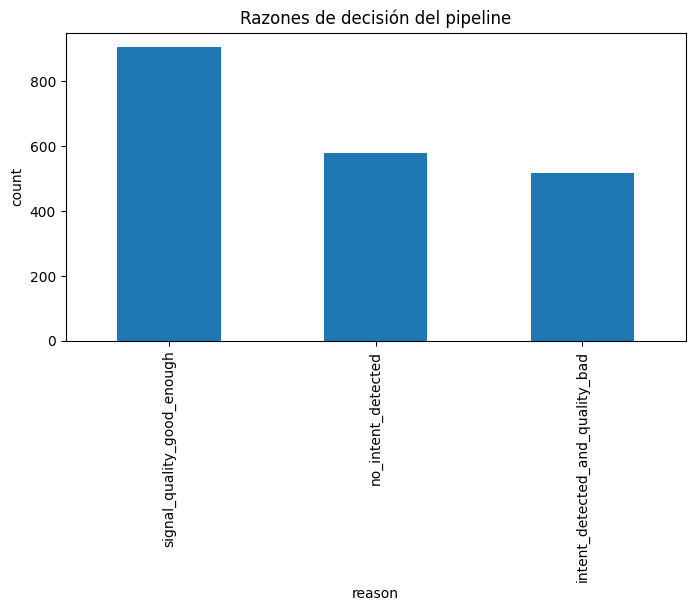

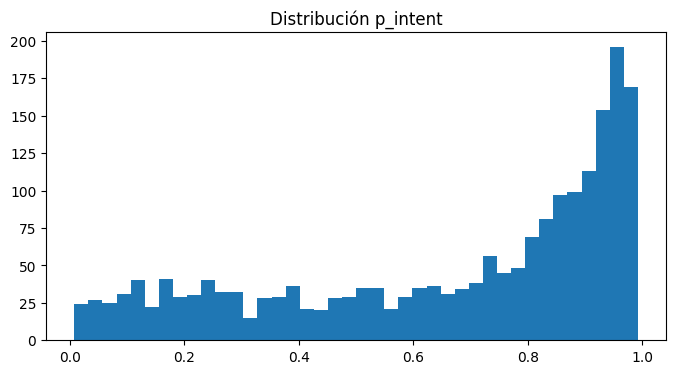

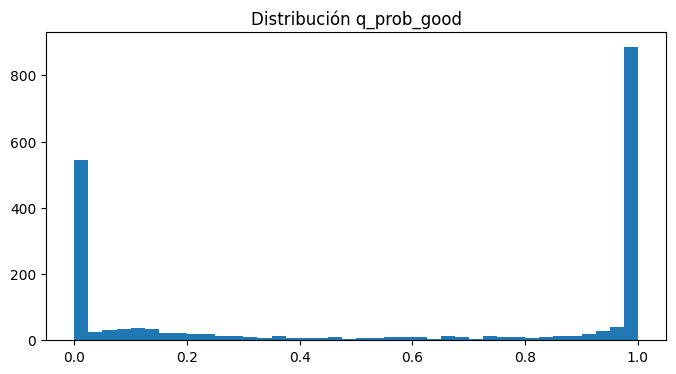

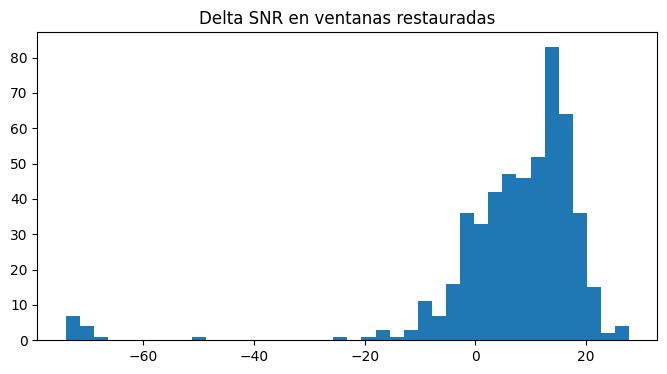

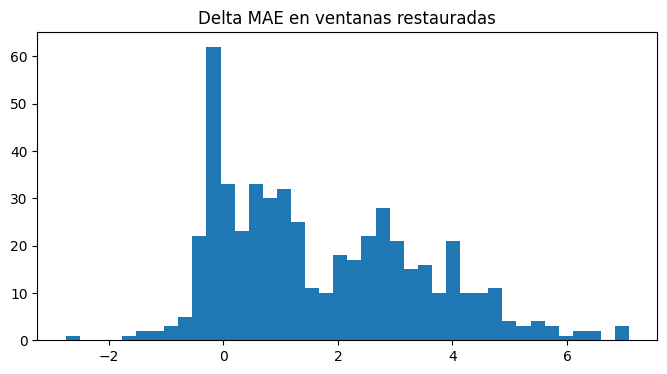

In [9]:
# =========================
# CELDA 8: Gráficas
# =========================
plt.figure(figsize=(8,4))
df["reason"].value_counts().plot(kind="bar")
plt.title("Razones de decisión del pipeline")
plt.ylabel("count")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(df["p_intent"], bins=40)
plt.title("Distribución p_intent")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(df["q_prob_good"], bins=40)
plt.title("Distribución q_prob_good")
plt.show()

dfr = df[df["decision"] == "restore"]
if len(dfr):
    plt.figure(figsize=(8,4))
    plt.hist(dfr["snr_after"] - dfr["snr_before"], bins=40)
    plt.title("Delta SNR en ventanas restauradas")
    plt.show()

    plt.figure(figsize=(8,4))
    plt.hist(dfr["mae_before"] - dfr["mae_after"], bins=40)
    plt.title("Delta MAE en ventanas restauradas")
    plt.show()

idx=1
decision=skip_restore
reason=no_intent_detected
p_intent=0.278
q_score_pred=0.950
q_prob_good=0.997
MAE: 0.0788 -> 0.0788
SNR: 34.55 -> 34.55


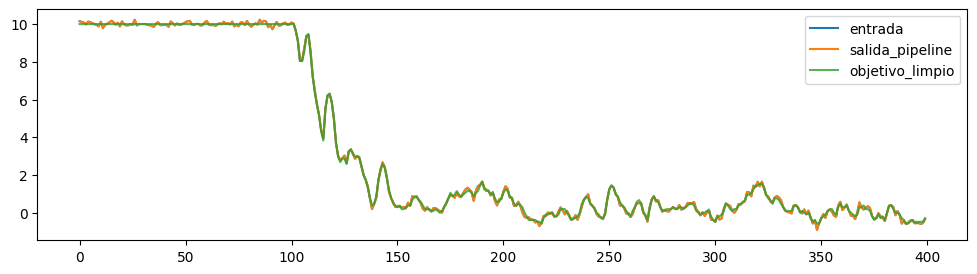

idx=2
decision=skip_restore
reason=signal_quality_good_enough
p_intent=0.941
q_score_pred=1.000
q_prob_good=1.000
MAE: 0.2826 -> 0.2826
SNR: 28.00 -> 28.00


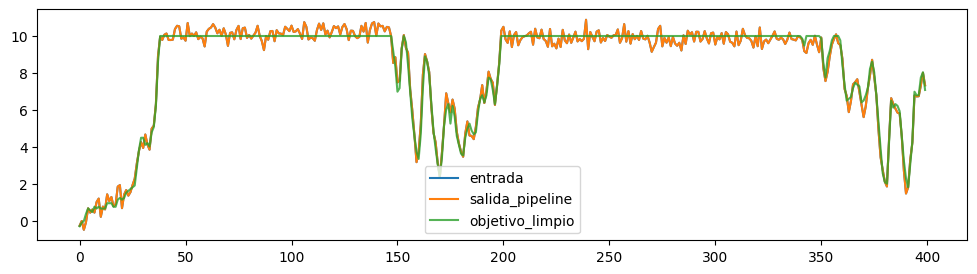

idx=4
decision=skip_restore
reason=signal_quality_good_enough
p_intent=0.924
q_score_pred=1.000
q_prob_good=1.000
MAE: 0.1485 -> 0.1485
SNR: 33.53 -> 33.53


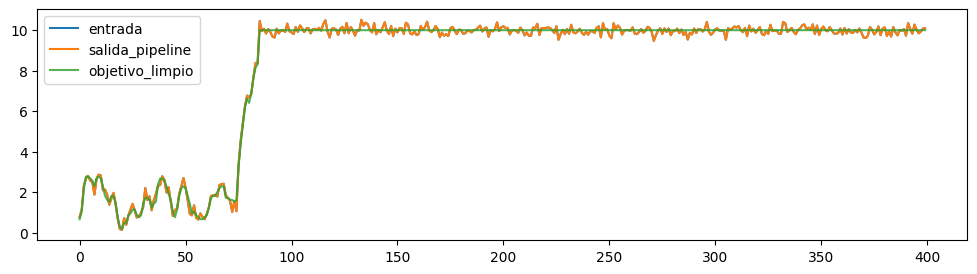

idx=0
decision=restore
reason=intent_detected_and_quality_bad
p_intent=0.885
q_score_pred=0.366
q_prob_good=0.000
MAE: 2.0268 -> 0.3511
SNR: 6.71 -> 20.61


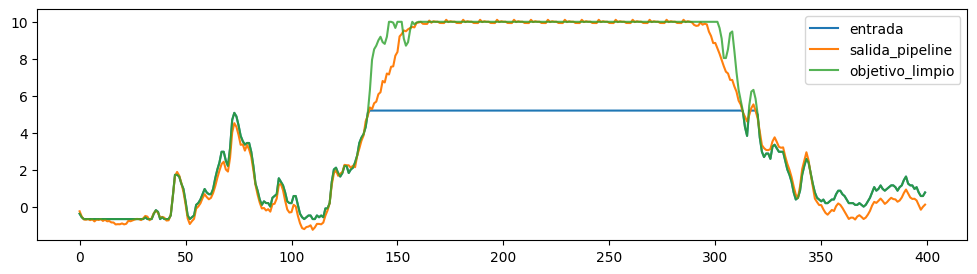

idx=3
decision=restore
reason=intent_detected_and_quality_bad
p_intent=0.621
q_score_pred=0.423
q_prob_good=0.005
MAE: 1.8779 -> 0.3623
SNR: 8.38 -> 21.05


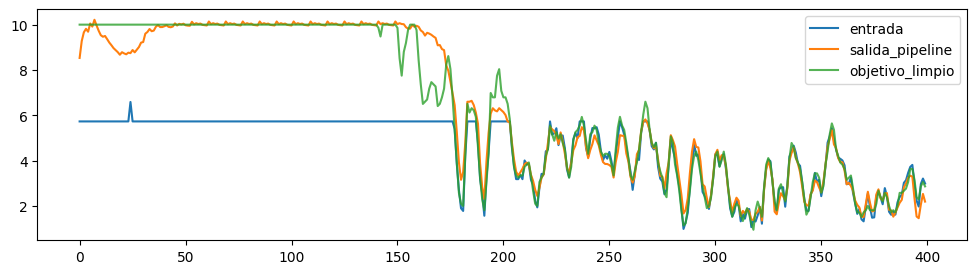

idx=6
decision=restore
reason=intent_detected_and_quality_bad
p_intent=0.886
q_score_pred=0.512
q_prob_good=0.124
MAE: 1.0194 -> 0.2984
SNR: 8.44 -> 23.68


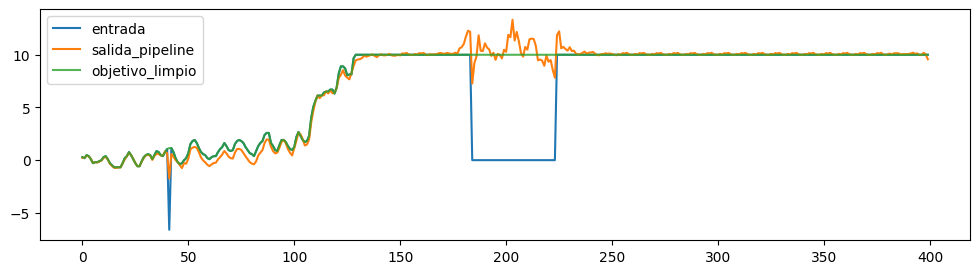

In [10]:
# =========================
# CELDA 9: Ejemplos explicados
# =========================
def show_example(i):
    row = df.iloc[i]
    clean = x_clean[i,0]
    corr  = x_corr[i,0]
    out   = x_out[i,0]

    print(f"idx={i}")
    print(f"decision={row['decision']}")
    print(f"reason={row['reason']}")
    print(f"p_intent={row['p_intent']:.3f}")
    print(f"q_score_pred={row['q_score_pred']:.3f}")
    print(f"q_prob_good={row['q_prob_good']:.3f}")
    print(f"MAE: {row['mae_before']:.4f} -> {row['mae_after']:.4f}")
    print(f"SNR: {row['snr_before']:.2f} -> {row['snr_after']:.2f}")

    plt.figure(figsize=(12,3))
    plt.plot(corr, label="entrada")
    plt.plot(out, label="salida_pipeline")
    plt.plot(clean, label="objetivo_limpio", alpha=0.8)
    plt.legend()
    plt.show()

idx_skip = df.index[df["decision"] == "skip_restore"][:3]
for i in idx_skip:
    show_example(int(i))

idx_rest = df.index[df["decision"] == "restore"][:3]
for i in idx_rest:
    show_example(int(i))